In [1]:
import gzip
import json
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In case of directory error

In [2]:
import os
print(os.getcwd())

c:\Users\aiden\OneDrive\Desktop\DS3-LocalLens


In [3]:
def load_json_gzp(path: str) -> pd.DataFrame:
    """
    Loads gzip-compressed JSON Lines:
      {"a":1}\n{"a":2}\n...
    """
    records = []
    with gzip.open(path, "rt", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

meta_path = "data/meta-Virginia.json.gz"
review_path = "data/review-Virginia.json.gz"

df_meta = load_json_gzp(meta_path)
df_review = load_json_gzp(review_path)

Keep only business id, avg rating, and total # of reviews. Drop rows with missing values

In [4]:
biz = df_meta[["gmap_id", "avg_rating", "num_of_reviews"]].dropna()

biz["num_of_reviews"] = biz["num_of_reviews"].astype(int)
biz["avg_rating"] = biz["avg_rating"].astype(float)


In [5]:
#X-axis labels and bins
bins = [1, 2, 5, 10, 20, 50, 100, 200, 500, 1000, biz["num_of_reviews"].max() + 1]
labels = [f"{bins[i]}–{bins[i+1]-1}" for i in range(len(bins)-1)]

biz["review_bin"] = pd.cut(biz["num_of_reviews"], bins=bins, labels=labels, right=False)

#Calculate statistics for each bin
stability_table = (biz.groupby("review_bin").agg(
        n_businesses=("gmap_id", "count"),
        rating_std=("avg_rating", "std"),
        rating_var=("avg_rating", "var"),
        mean_rating=("avg_rating", "mean"),
    ).reset_index())


print(stability_table)

  review_bin  n_businesses  rating_std  rating_var  mean_rating
0        1–1          4228    1.223072    1.495906     4.271949
1        2–4         10213    0.875691    0.766835     4.282415
2        5–9         19405    0.722017    0.521309     4.263679
3      10–19         15062    0.661144    0.437111     4.256619
4      20–49         21531    0.620459    0.384970     4.268069
5      50–99         16440    0.567684    0.322265     4.286089
6    100–199         12988    0.492077    0.242140     4.310371
7    200–499         12316    0.451288    0.203661     4.282941
8    500–999          5013    0.410508    0.168517     4.214981
9  1000–9998          2477    0.381416    0.145479     4.251756


C:\Users\aiden\AppData\Local\Temp\ipykernel_36988\1771088084.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stability_table = (biz.groupby("review_bin").agg(


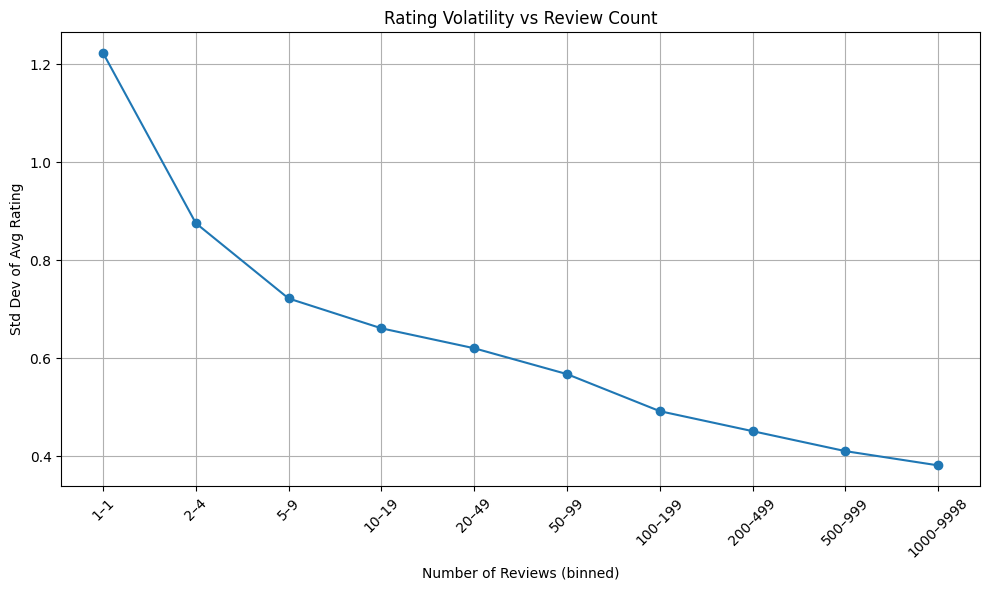

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(stability_table["review_bin"], stability_table["rating_std"], marker="o")
plt.xticks(rotation=45)
plt.ylabel("Std Dev of Avg Rating")
plt.xlabel("Number of Reviews (binned)")
plt.title("Rating Volatility vs Review Count")
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
biz = df_meta[["gmap_id", "avg_rating", "num_of_reviews", "category"]].dropna()

# Each row now has one category because some of the businesses had more than one category
biz_exploded = biz.explode('category')

# Find top 10 (so graph isn't cluttered)
top_cats = biz_exploded['category'].value_counts().head(10).index.tolist()

# Only top 10
df_filtered = biz_exploded[biz_exploded['category'].isin(top_cats)].copy()

bins = [0, 5, 10, 20, 50, 100, 250, 500, 1000, 5000]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100', '101-250', '251-500', '501-1k', '1k+']
df_filtered['review_bin'] = pd.cut(df_filtered['num_of_reviews'], bins=bins, labels=labels)

# Get variance of avg rating
stability_data = df_filtered.groupby(['category', 'review_bin'], observed=True)['avg_rating'].var().reset_index()

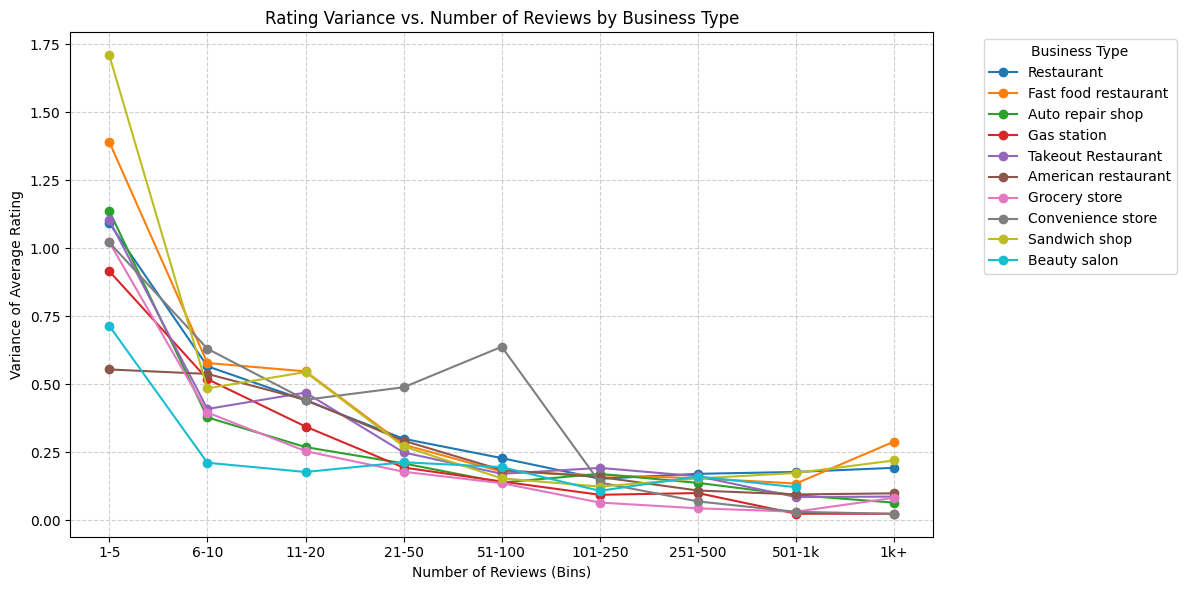

In [8]:
plt.figure(figsize=(12, 6))

for cat in top_cats:
    subset = stability_data[stability_data['category'] == cat]
    plt.plot(subset['review_bin'], subset['avg_rating'], marker='o', label=cat)

plt.title('Rating Variance vs. Number of Reviews by Business Type')
plt.xlabel('Number of Reviews (Bins)')
plt.ylabel('Variance of Average Rating')
plt.legend(title='Business Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()